<a href="https://colab.research.google.com/github/olajidechris/CollabProjects/blob/main/Creating_N_gram_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Creating N-gram models

Extracting n-gram counts and using them to build a language model.

In [ ]:
import random # for sampling based on probability distrubitions
import textwrap # for automatically adding linebreaks to long texts
import pandas as pd # for constructing and visualizing tables
import numpy as np # for processing numbers quickly
from collections import Counter, defaultdict # for counting ngrams

print("Setup complete.")

Setup complete.


Run the following cell to download the dataset.

In [ ]:
# import sample dataset json
sample_dataset = pd.read_json(
    "https://storage.googleapis.com/dm-educational/assets/ai_foundations/africa_galore.json"
)

# extract only the text columns into a pandas series
dataset = sample_dataset["description"]

print(f"The dataset consists of {dataset.shape[0]} paragraphs.")

The dataset consists of 232 paragraphs.


To get a sense of what the dataset looks like, inspect the first five text sequences in the dataset.

In [ ]:
for text_sequence in dataset[:5]:
    # textwrap automatically adds line breaks to make long texts more readable.
    formatted_paragraph = textwrap.fill(text_sequence)
    print(f"{formatted_paragraph}\n")

The Lagos air was thick with humidity, but the energy in the club was
electric. The band launched into a hypnotic Afrobeat groove, the drums
pounding out a complex polyrhythm, the horns blaring a soaring melody,
and the bass laying down a deep, funky foundation. A woman named Imani
moved effortlessly to the music, her body swaying in time with the
rhythm. The music seemed to flow through her, a powerful current of
energy and joy. All around her, people were dancing, singing, and
clapping, caught up in the infectious rhythm. The music was more than
just entertainment; it was a celebration of life, a connection to
their shared heritage, a vibrant expression of the soul of Lagos.

The warm evening air in Accra was filled with the lilting melodies of
Highlife music. At a small bar tucked away on a side street, a band
played, the guitars weaving intricate patterns, the horns adding a
bright, joyful counterpoint. Kwame, a man with a wistful smile, sat at
a table nursing a beer, lost in the m

The text sequences are currently one long string. In order to split the dataset into n-grams and count them in order to use them to build a language model, the text sequences need to be split into individual words. This process is referred to as **tokenization**.

In [ ]:
def space_tokenize(text: str) -> list[str]:
    """
    Splits a string into a list of words (tokens).
    Splits text on space character.

    Args:
        text: The input text.

    Returns:
        A list of tokens. Returns empty list if text is empty or all spaces.
    """
    tokens = text.split(" ")
    return tokens

# Tokenize an example text with the `space_tokenize` function.
space_tokenize("Kanga, a colorful printed cloth is more than just a fabric.")

['Kanga,',
 'a',
 'colorful',
 'printed',
 'cloth',
 'is',
 'more',
 'than',
 'just',
 'a',
 'fabric.']

Tokenizing the first paragraph in the dataset.

In [ ]:
space_tokenize(dataset[0])

['The',
 'Lagos',
 'air',
 'was',
 'thick',
 'with',
 'humidity,',
 'but',
 'the',
 'energy',
 'in',
 'the',
 'club',
 'was',
 'electric.',
 'The',
 'band',
 'launched',
 'into',
 'a',
 'hypnotic',
 'Afrobeat',
 'groove,',
 'the',
 'drums',
 'pounding',
 'out',
 'a',
 'complex',
 'polyrhythm,',
 'the',
 'horns',
 'blaring',
 'a',
 'soaring',
 'melody,',
 'and',
 'the',
 'bass',
 'laying',
 'down',
 'a',
 'deep,',
 'funky',
 'foundation.',
 'A',
 'woman',
 'named',
 'Imani',
 'moved',
 'effortlessly',
 'to',
 'the',
 'music,',
 'her',
 'body',
 'swaying',
 'in',
 'time',
 'with',
 'the',
 'rhythm.',
 'The',
 'music',
 'seemed',
 'to',
 'flow',
 'through',
 'her,',
 'a',
 'powerful',
 'current',
 'of',
 'energy',
 'and',
 'joy.',
 'All',
 'around',
 'her,',
 'people',
 'were',
 'dancing,',
 'singing,',
 'and',
 'clapping,',
 'caught',
 'up',
 'in',
 'the',
 'infectious',
 'rhythm.',
 'The',
 'music',
 'was',
 'more',
 'than',
 'just',
 'entertainment;',
 'it',
 'was',
 'a',
 'celebration

### Generating N-grams

Now that we can tokenize text into individual words, the next step is to group these tokens into sequences of $n$ consecutive words, known as **n-grams**.

We will define a function `generate_ngrams` that sliding-windows across the list of tokens to create these sequences.

In [ ]:
def generate_ngrams(text: str, n: int) -> list[tuple[str]]:
    """
    Generates n-grams from a given text.

    Args:
        text: The input text string.
        n: The size of the n-grams (e.g., 2 for bigrams, 3 for trigrams).

    Returns:
        A list of n-grams, each represented as a list of tokens.
    """

    # Tokenize text.
    tokens = space_tokenize(text)  # Add your code here.

    # define the offset for the context window
    offset = n - 1

    # Initialize and construct the list of n-grams.
    ngrams = [tuple(tokens[i:i+n]) for i in range(len(tokens)-offset)]

    return ngrams


### Tokenizing the Dataset

With our n-gram generator ready, we can process the entire dataset. We will iterate through every description and extract unigrams, bigrams, trigrams, and quadgrams to build our vocabulary and frequency distributions.

In [ ]:
unigram_tokens = []
bigram_tokens = []
trigram_tokens = []
quadgram_tokens = []

for text_sequence in dataset:
# Calling `generate_ngrams` with n=1 constructs a list of unigrams.
    unigram_tokens.extend(generate_ngrams(text_sequence, n=1))
# Calling `generate_ngrams` with n=2 constructs a list of bigrams (2-grams).
    bigram_tokens.extend(generate_ngrams(text_sequence, n=2))
# Calling `generate_ngrams` with n=3 constructs a list of trigrams (3-grams).
    trigram_tokens.extend(generate_ngrams(text_sequence, n=3))
# Calling `generate_ngrams` with n=4 constructs a list of 4-grams (4-grams).
    quadgram_tokens.extend(generate_ngrams(text_sequence, n=3))

print("First 10 Unigrams:", unigram_tokens[:10])
print("First 10 Bigrams:", bigram_tokens[:10])
print("First 10 Trigrams:", trigram_tokens[:10])
print("First 10 Quadgrams:", quadgram_tokens[:10])

First 10 Unigrams: [('The',), ('Lagos',), ('air',), ('was',), ('thick',), ('with',), ('humidity,',), ('but',), ('the',), ('energy',)]
First 10 Bigrams: [('The', 'Lagos'), ('Lagos', 'air'), ('air', 'was'), ('was', 'thick'), ('thick', 'with'), ('with', 'humidity,'), ('humidity,', 'but'), ('but', 'the'), ('the', 'energy'), ('energy', 'in')]
First 10 Trigrams: [('The', 'Lagos', 'air'), ('Lagos', 'air', 'was'), ('air', 'was', 'thick'), ('was', 'thick', 'with'), ('thick', 'with', 'humidity,'), ('with', 'humidity,', 'but'), ('humidity,', 'but', 'the'), ('but', 'the', 'energy'), ('the', 'energy', 'in'), ('energy', 'in', 'the')]
First 10 Quadgrams: [('The', 'Lagos', 'air'), ('Lagos', 'air', 'was'), ('air', 'was', 'thick'), ('was', 'thick', 'with'), ('thick', 'with', 'humidity,'), ('with', 'humidity,', 'but'), ('humidity,', 'but', 'the'), ('but', 'the', 'energy'), ('the', 'energy', 'in'), ('energy', 'in', 'the')]


### Counting N-gram Frequencies

To understand which word sequences are most common in our dataset, we use the `Counter` object. This allows us to see the frequency of specific bigrams, trigrams, and quadgrams.

In [ ]:
# Use the Python Counter data type for computing the counts of ngrams.
bigram_counts = Counter(bigram_tokens)
trigram_counts = Counter(trigram_tokens)
quadgram_counts = Counter(quadgram_tokens)

# Print the 10 most common grams.
print("Top 10 Bigrams:")
for bigram, count in bigram_counts.most_common(10):
    print(f"  ({bigram}, {count})")

print("\nTop 10 Trigrams:")
for trigram, count in trigram_counts.most_common(10):
    print(f"  ({trigram}, {count})")

print("\nTop 10 Quadgrams:")
for quadgram, count in quadgram_counts.most_common(10):
    print(f"  ({quadgram}, {count})")

Top 10 Bigrams:
  (('is', 'a'), 144)
  (('of', 'the'), 100)
  (('and', 'the'), 69)
  (('in', 'the'), 61)
  (('with', 'a'), 60)
  (('in', 'a'), 55)
  (('and', 'a'), 50)
  (('to', 'the'), 42)
  (('was', 'a'), 39)
  (('It', 'is'), 33)

Top 10 Trigrams:
  (('went', 'looking', 'for'), 32)
  (('a', 'symbol', 'of'), 18)
  (('was', 'hungry', 'so'), 18)
  (('The', 'result', 'is'), 17)
  (('looking', 'for', 'a'), 17)
  (('she', 'went', 'looking'), 16)
  (('he', 'went', 'looking'), 16)
  (('result', 'is', 'a'), 15)
  (('so', 'he', 'went'), 14)
  (('so', 'she', 'went'), 14)

Top 10 Quadgrams:
  (('went', 'looking', 'for'), 32)
  (('a', 'symbol', 'of'), 18)
  (('was', 'hungry', 'so'), 18)
  (('The', 'result', 'is'), 17)
  (('looking', 'for', 'a'), 17)
  (('she', 'went', 'looking'), 16)
  (('he', 'went', 'looking'), 16)
  (('result', 'is', 'a'), 15)
  (('so', 'he', 'went'), 14)
  (('so', 'she', 'went'), 14)


### Visualizing N-gram Distributions

Visualizing the most frequent n-grams helps us identify patterns in the text, such as common phrases or structural repetitions in the descriptions.

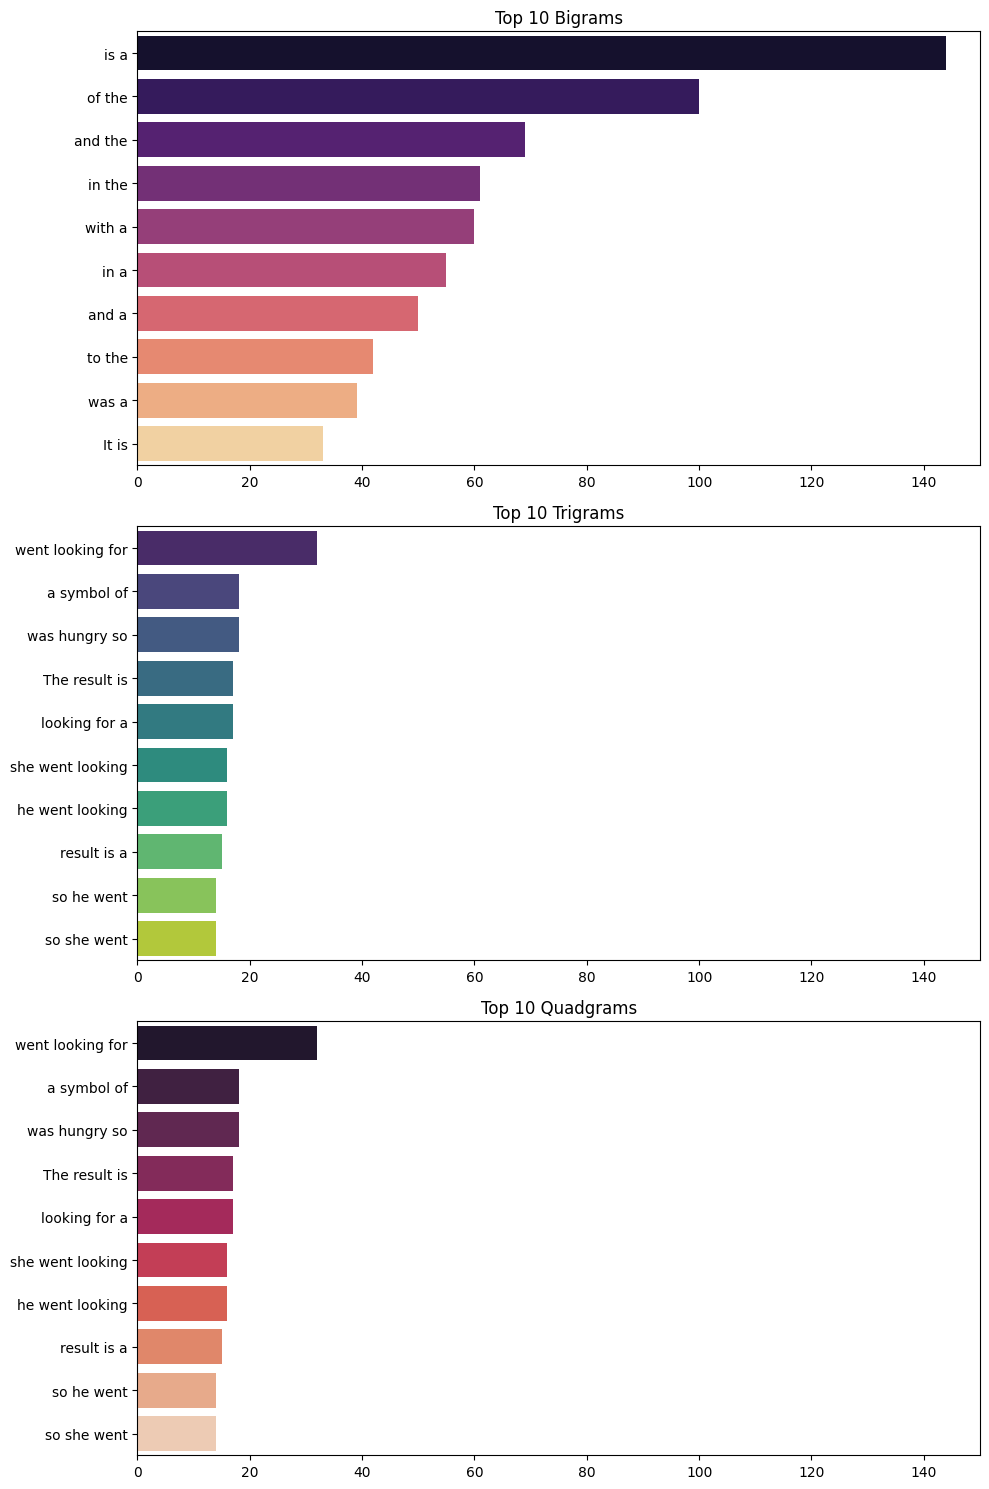

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Helper to prepare data
def get_plot_data(counter_obj):
    top = counter_obj.most_common(10)
    labels = [' '.join(gram) for gram, count in top]
    counts = [count for gram, count in top]
    return labels, counts

# Get data for each n-gram type
b_labels, b_counts = get_plot_data(bigram_counts)
t_labels, t_counts = get_plot_data(trigram_counts)
q_labels, q_counts = get_plot_data(quadgram_counts)

# Set up the figure with three subplots
fig, axes = plt.subplots(3, 1, figsize=(10, 15))

# Plot Bigrams
sns.barplot(x=b_counts, y=b_labels, ax=axes[0],
            palette='magma', hue=b_labels, legend=False)
axes[0].set_title('Top 10 Bigrams')
axes[0].set_xlim(0, 150)

# Plot Trigrams
sns.barplot(x=t_counts, y=t_labels, ax=axes[1],
            palette='viridis', hue=t_labels, legend=False)
axes[1].set_title('Top 10 Trigrams')
axes[1].set_xlim(0, 150)

# Plot Quadgrams
sns.barplot(x=q_counts, y=q_labels, ax=axes[2],
            palette='rocket', hue=q_labels, legend=False)
axes[2].set_title('Top 10 Quadgrams')
axes[2].set_xlim(0, 150)

plt.tight_layout()
plt.show()

### Mapping Contexts to Next Tokens

To build a predictive model, we need to restructure our counts. Instead of just knowing how often a whole n-gram occurs, we want to know: *Given a specific context (the first $n-1$ words), what words are likely to follow?*

The `get_ngram_counts` function creates a mapping from a context string to a counter of possible following words.

In [ ]:
def get_ngram_counts(dataset: list[str], n: int) -> dict[str, Counter]:
    """Computes the n-gram counts from a dataset.

    This function takes a list of text strings (paragraphs or sentences) as
    input, constructs n-grams from each text, and creates a dictionary where:

    * Keys represent n-1 token long contexts `context`.
    * Values are a Counter object `counts` such that `counts[next_token]` is the
      count of `next_token` following `context`.

    Args:
        dataset: The list of text strings in the dataset.
        n: The size of the n-grams to generate (e.g., 2 for bigrams, 3 for
            trigrams).

    Returns:
        A dictionary where keys are (n-1)-token contexts and values are Counter
        objects storing the counts of each next token for that context.

    """

    # Define the dictionary as a defaultdict that is automatically initialized
    # with an empty Counter object. This allows you to access and set the value
    # of ngram_counts[context][next_token] without initializing
    # ngram_counts[context] or ngram_counts[context][next_token] first.
    # Reference
    # https://docs.python.org/3/library/collections.html#collections.Counter and
    # https://docs.python.org/3/library/collections.html#collections.defaultdict
    # for more information on how to use defaultdict and Counter types.
    ngram_counts = defaultdict(Counter)

    # paragraph is a stand in for item in each row of the description column
    # of a pandas series
    for paragraph in dataset:
        # Add your code here.
        # Iterate through each tuple in the generated list of tuples
        for ngram in generate_ngrams(paragraph, n):
            # create a context str
            context = " ".join(ngram[:-1])
            # creat a next token str with the last word in tuple
            next_token = ngram[-1]
            # assign to Counter object as context:{next_token:incrementor}
            ngram_counts[context][next_token] += 1
            #if next_token == "name":
            #  print(context)

    return dict(ngram_counts)

### Calculating Probabilities

Finally, we convert our raw counts into probabilities. By dividing the count of a specific next-word by the total number of times the context appeared, we get the maximum likelihood estimate of the next word's probability.

In [ ]:
def build_ngram_model(
    dataset: list[str],
    n: int
) -> dict[str, dict[str, float]]:
    """Builds an n-gram language model.

    This function takes a list of text strings (paragraphs or sentences) as
    input, generates n-grams from each text using the function get_ngram_counts
    and converts them into probabilities.  The resulting model is a dictionary,
    where keys are (n-1)-token contexts and values are dictionaries mapping
    possible next tokens to their conditional probabilities given the context.

    Args:
        dataset: A list of text strings representing the dataset.
        n: The size of the n-grams (e.g., 2 for a bigram model).

    Returns:
        A dictionary representing the n-gram language model, where keys are
        (n-1)-tokens contexts and values are dictionaries mapping possible next
        tokens to their conditional probabilities.
    """

    # A dictionary to store P(B | A).
    # ngram_model[context][token] should store P(token | context).
    ngram_model = {}

    # Use the ngram_counts as computed by the get_ngram_counts function.
    ngram_counts = get_ngram_counts(dataset, n)

    # Loop through the possible contexts. `context` is a string
    # and `next_tokens` is a dictionary mapping possible next tokens to their
    # counts of following `context`.
    for context, next_tokens in ngram_counts.items():

        # Compute Count(A) and P(B | A) here.
        # Add your code here.
        count_a = next_tokens.total()
        ngram_model[context] = {
            token: next_tokens[token] / count_a for token in next_tokens
        }

    return ngram_model

### Building and Inspecting the N-gram Model

We will now use `build_ngram_model` to create a bigram model ($n=2$) and look at the probability distributions for specific contexts.

In [ ]:
# Build a bigram model (n=2)
# Ensure build_ngram_model is available
bigram_model = build_ngram_model(dataset, n=2)

# Function to display probabilities for a specific context
def inspect_context(model, context):
    if context in model:
        print(f"Probabilities for context '{context}':")
        # Sort by probability descending
        sorted_probs = sorted(model[context].items(), key=lambda item: item[1], reverse=True)
        for token, prob in sorted_probs[:10]:
            print(f"  '{token}': {prob:.4f}")
    else:
        print(f"Context '{context}' not found in the model.")

# Inspect some common contexts
inspect_context(bigram_model, "is")
print()
inspect_context(bigram_model, "The")

Probabilities for context 'is':
  'a': 0.3956
  'the': 0.0522
  'made': 0.0412
  'often': 0.0385
  'typically': 0.0220
  'usually': 0.0192
  'characterized': 0.0165
  'also': 0.0165
  'one': 0.0165
  'used': 0.0137

Probabilities for context 'The':
  'result': 0.0691
  'air': 0.0407
  'music': 0.0163
  'park's': 0.0163
  'park': 0.0163
  'stew': 0.0163
  'vibrant': 0.0122
  'process': 0.0122
  'warm,': 0.0122
  'rice': 0.0122
